# 03 Modeling

This notebook documents the **Modeling** phase.

Final modeling design:
1. Train/compare four algorithms on the best non-node2vec temporal graph feature set.
2. Select the strongest model family using validation PR-AUC and operational alert quality.
3. Add split-safe node2vec embeddings to LightGBM as the final advanced extension.

Algorithms compared:
- Logistic Regression,
- Random Forest,
- XGBoost,
- LightGBM.

Class imbalance strategy:
- chronological split,
- train-only negative undersampling,
- class weighting / `scale_pos_weight`,
- PR-AUC, F1, precision, recall, alert count, and Top-K metrics.

In [1]:
from pathlib import Path
import sys

# Works when launched from repository root or from notebooks/.
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def read_table(name: str, fallback_rows=None) -> pd.DataFrame:
    """Read a report CSV from common locations; fallback rows make the notebook displayable."""
    candidate_paths = [
        TABLES_DIR / name,
        PROJECT_ROOT / name,
        Path("/mnt/data") / name,  # useful only in ChatGPT sandbox
    ]
    for path in candidate_paths:
        if path.exists():
            print(f"Loaded {name} from {path}")
            return pd.read_csv(path)
    if fallback_rows is not None:
        print(f"Using embedded fallback rows for {name}")
        return pd.DataFrame(fallback_rows)
    raise FileNotFoundError("Could not find " + name + " in:\n" + "\n".join(str(p) for p in candidate_paths))

import joblib

PROJECT_ROOT: /home/acer/dev/aml-graph-dm


## 1. Training commands

The heavy training is handled by scripts so the notebook stays clean and reproducible.

In [2]:
print("Build current best non-node2vec feature table:")
print("PYTHONPATH=. python scripts/build_features.py --dataset HI-Small --nrows 2000000 --use-historical-graph --use-rolling-graph --use-advanced-graph")

print("\nRun four-model comparison:")
print("PYTHONPATH=. python scripts/train_four_models_fast.py --neg-per-pos 100 --include-graph")

print("\nRun split-safe node2vec extension:")
print("PYTHONPATH=. python scripts/train_lgbm_node2vec.py --neg-per-pos 100 --dimensions 16 --walk-length 10 --num-walks 5 --workers 4 --max-edges 300000")

Build current best non-node2vec feature table:
PYTHONPATH=. python scripts/build_features.py --dataset HI-Small --nrows 2000000 --use-historical-graph --use-rolling-graph --use-advanced-graph

Run four-model comparison:
PYTHONPATH=. python scripts/train_four_models_fast.py --neg-per-pos 100 --include-graph

Run split-safe node2vec extension:
PYTHONPATH=. python scripts/train_lgbm_node2vec.py --neg-per-pos 100 --dimensions 16 --walk-length 10 --num-walks 5 --workers 4 --max-edges 300000


## 2. Experiment design matrix

The project does **not** train every model on every feature set. The design separates two questions:

1. **Feature ablation:** use LightGBM to test whether graph features improve performance.
2. **Algorithm comparison:** use four algorithms once on the strongest non-node2vec feature set.
3. **Final extension:** use LightGBM + split-safe node2vec to test whether graph embeddings improve the selected model family.

This keeps the experiment defensible without creating an unnecessary 4 × many-feature-set grid.

In [3]:
experiment_design = pd.DataFrame([
    {"experiment":"E1", "question":"Feature ablation", "feature_set":"Raw only", "models":"LightGBM", "purpose":"Baseline transaction features"},
    {"experiment":"E2", "question":"Feature ablation", "feature_set":"Historical graph", "models":"LightGBM", "purpose":"Past sender/receiver/pair behavior"},
    {"experiment":"E3", "question":"Feature ablation", "feature_set":"Historical + rolling graph", "models":"LightGBM", "purpose":"Short-term activity bursts"},
    {"experiment":"E4", "question":"Feature ablation", "feature_set":"Historical + rolling + advanced graph", "models":"LightGBM", "purpose":"Centrality and motif/cycle proxy"},
    {"experiment":"E5", "question":"Attempted feature group", "feature_set":"Snapshot PageRank/community", "models":"LightGBM", "purpose":"Past snapshot network position"},
    {"experiment":"E6", "question":"Algorithm comparison", "feature_set":"Best non-node2vec advanced graph", "models":"Logistic Regression, Random Forest, XGBoost, LightGBM", "purpose":"Satisfy >3 algorithm comparison"},
    {"experiment":"E7", "question":"Final extension", "feature_set":"Advanced graph + split-safe node2vec", "models":"LightGBM", "purpose":"Final model candidate"},
])

display(experiment_design)
experiment_design.to_csv(TABLES_DIR / "experiment_design_matrix.csv", index=False)
print("Saved:", TABLES_DIR / "experiment_design_matrix.csv")

,experiment,question,feature_set,models,purpose
0,E1,Feature ablation,Raw only,LightGBM,Baseline transaction features
1,E2,Feature ablation,Historical graph,LightGBM,Past sender/receiver/pair behavior
2,E3,Feature ablation,Historical + rolling graph,LightGBM,Short-term activity bursts
3,E4,Feature ablation,Historical + rolling + advanced graph,LightGBM,Centrality and motif/cycle proxy
4,E5,Attempted feature group,Snapshot PageRank/community,LightGBM,Past snapshot network position
5,E6,Algorithm comparison,Best non-node2vec advanced graph,"Logistic Regression, Random Forest, XGBoost, L...",Satisfy >3 algorithm comparison
6,E7,Final extension,Advanced graph + split-safe node2vec,LightGBM,Final model candidate


Saved: /home/acer/dev/aml-graph-dm/reports/tables/experiment_design_matrix.csv


## 3. Class imbalance strategy

AML is a rare-event classification task. The final modeling scripts use:

- chronological split,
- train-only negative undersampling,
- `neg_per_pos = 100`,
- class weighting (`scale_pos_weight`, `class_weight='balanced'`, or `balanced_subsample`),
- PR-AUC/F1/precision/recall/Top-K instead of accuracy.

In [4]:
imbalance_strategy = pd.DataFrame([
    {"step":"Chronological split", "purpose":"Avoid future-information leakage and simulate prospective scoring"},
    {"step":"Train-only negative undersampling", "purpose":"Keep all laundering rows but sample normal rows for feasible training"},
    {"step":"neg_per_pos = 100", "purpose":"Use 100 normal training rows per laundering training row"},
    {"step":"Class weighting", "purpose":"Make laundering errors more costly during training"},
    {"step":"PR-AUC and Top-K", "purpose":"Evaluate ranking quality under extreme imbalance"},
])

display(imbalance_strategy)
imbalance_strategy.to_csv(TABLES_DIR / "class_imbalance_strategy.csv", index=False)
print("Saved:", TABLES_DIR / "class_imbalance_strategy.csv")

,step,purpose
0,Chronological split,Avoid future-information leakage and simulate ...
1,Train-only negative undersampling,Keep all laundering rows but sample normal row...
2,neg_per_pos = 100,Use 100 normal training rows per laundering tr...
3,Class weighting,Make laundering errors more costly during trai...
4,PR-AUC and Top-K,Evaluate ranking quality under extreme imbalance


Saved: /home/acer/dev/aml-graph-dm/reports/tables/class_imbalance_strategy.csv


## 2. Four-algorithm comparison result

This satisfies the bonus requirement for using more than three algorithms. The selected model family is based on validation PR-AUC, not test PR-AUC.

In [5]:
four_model_fallback = [
    {"model":"lightgbm","feature_set":"raw_plus_temporal_graph","neg_per_pos":100,"feature_count":92,"train_sample_rows":36461,"train_sample_pos":361,"train_sample_neg":36100,"val_pr_auc":0.035802,"val_f1":0.073724,"val_precision":0.041292,"val_recall":0.343612,"test_pr_auc":0.081038,"test_f1":0.154743,"test_precision":0.109683,"test_recall":0.262637,"test_tp":239,"test_fp":1940,"test_tn":397150,"test_fn":671,"test_alert_count":2179},
    {"model":"xgboost","feature_set":"raw_plus_temporal_graph","neg_per_pos":100,"feature_count":92,"train_sample_rows":36461,"train_sample_pos":361,"train_sample_neg":36100,"val_pr_auc":0.032368,"val_f1":0.038728,"val_precision":0.020178,"val_recall":0.480176,"test_pr_auc":0.053348,"test_f1":0.108758,"test_precision":0.063674,"test_recall":0.372527,"test_tp":339,"test_fp":4985,"test_tn":394105,"test_fn":571,"test_alert_count":5324},
    {"model":"random_forest","feature_set":"raw_plus_temporal_graph","neg_per_pos":100,"feature_count":92,"train_sample_rows":36461,"train_sample_pos":361,"train_sample_neg":36100,"val_pr_auc":0.023960,"val_f1":0.024277,"val_precision":0.012399,"val_recall":0.577093,"test_pr_auc":0.042708,"test_f1":0.092769,"test_precision":0.050570,"test_recall":0.560440,"test_tp":510,"test_fp":9575,"test_tn":389515,"test_fn":400,"test_alert_count":10085},
    {"model":"logistic_regression","feature_set":"raw_plus_temporal_graph","neg_per_pos":100,"feature_count":92,"train_sample_rows":36461,"train_sample_pos":361,"train_sample_neg":36100,"val_pr_auc":0.006419,"val_f1":0.006578,"val_precision":0.003301,"val_recall":0.942731,"test_pr_auc":0.133309,"test_f1":0.027266,"test_precision":0.013825,"test_recall":0.981319,"test_tp":893,"test_fp":63699,"test_tn":335391,"test_fn":17,"test_alert_count":64592},
]

four_model = read_table("four_model_comparison_temporal_graph_final.csv", four_model_fallback)
four_model_sorted = four_model.sort_values("val_pr_auc", ascending=False)
display(four_model_sorted)

Loaded four_model_comparison_temporal_graph_final.csv from /home/acer/dev/aml-graph-dm/reports/tables/four_model_comparison_temporal_graph_final.csv


,model,feature_set,neg_per_pos,feature_count,train_sample_rows,train_sample_pos,train_sample_neg,val_pr_auc,val_f1,val_precision,val_recall,test_pr_auc,test_f1,test_precision,test_recall,test_tp,test_fp,test_tn,test_fn,test_alert_count
0,lightgbm,raw_plus_temporal_graph,100,92,36461,361,36100,0.035802,0.073724,0.041292,0.343612,0.081038,0.154743,0.109683,0.262637,239,1940,397150,671,2179
1,xgboost,raw_plus_temporal_graph,100,92,36461,361,36100,0.032368,0.038728,0.020178,0.480176,0.053348,0.108758,0.063674,0.372527,339,4985,394105,571,5324
2,random_forest,raw_plus_temporal_graph,100,92,36461,361,36100,0.023960,0.024277,0.012399,0.577093,0.042708,0.092769,0.050570,0.560440,510,9575,389515,400,10085
3,logistic_regression,raw_plus_temporal_graph,100,92,36461,361,36100,0.006419,0.006578,0.003301,0.942731,0.133309,0.027266,0.013825,0.981319,893,63699,335391,17,64592


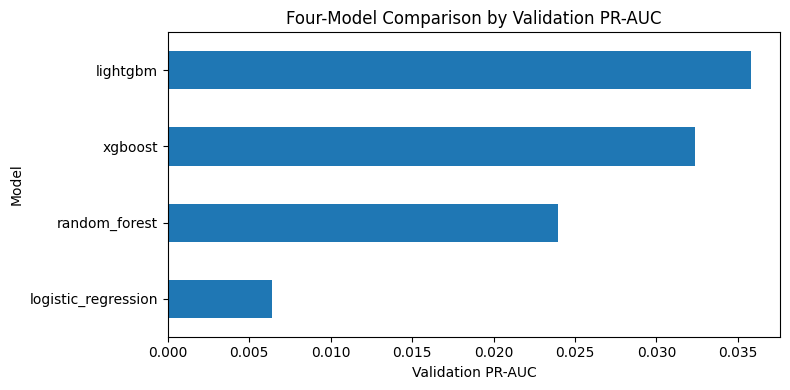

Saved: /home/acer/dev/aml-graph-dm/reports/figures/four_model_validation_pr_auc.png


In [6]:
ax = four_model_sorted.sort_values("val_pr_auc").plot(
    kind="barh",
    x="model",
    y="val_pr_auc",
    legend=False,
    figsize=(8, 4),
)
ax.set_title("Four-Model Comparison by Validation PR-AUC")
ax.set_xlabel("Validation PR-AUC")
ax.set_ylabel("Model")
plt.tight_layout()

out_path = FIGURES_DIR / "four_model_validation_pr_auc.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## 3. Node2vec final extension

Node2vec is trained only on the chronological training graph. The embeddings are then attached as sender and receiver vectors. This is split-safe because validation/test edges are not used to learn embeddings.

In [7]:
node2vec_fallback = [
    {"model":"lightgbm_node2vec","feature_set":"raw_plus_advanced_graph_plus_node2vec","neg_per_pos":100,"node2vec_dimensions":16,"node2vec_walk_length":10,"node2vec_num_walks":5,"node2vec_max_edges":300000,"feature_count":145,"val_pr_auc":0.040234,"val_f1":0.073801,"val_precision":0.041916,"val_recall":0.308370,"test_pr_auc":0.117686,"test_f1":0.181235,"test_precision":0.123315,"test_recall":0.341758,"test_tp":311,"test_fp":2211,"test_tn":396879,"test_fn":599,"test_alert_count":2522},
]
node2vec_metrics = read_table("lgbm_node2vec_metrics_final.csv", node2vec_fallback)
display(node2vec_metrics)

Loaded lgbm_node2vec_metrics_final.csv from /home/acer/dev/aml-graph-dm/reports/tables/lgbm_node2vec_metrics_final.csv


,model,feature_set,neg_per_pos,node2vec_dimensions,node2vec_walk_length,node2vec_num_walks,node2vec_max_edges,feature_count,val_pr_auc,val_f1,...,val_recall,test_pr_auc,test_f1,test_precision,test_recall,test_tp,test_fp,test_tn,test_fn,test_alert_count
0,lightgbm_node2vec,raw_plus_advanced_graph_plus_node2vec,100,16,10,5,300000,145,0.040234,0.073801,...,0.30837,0.117686,0.181235,0.123315,0.341758,311,2211,396879,599,2522


In [8]:
coverage_fallback = [
    {"split":"train","sender_known_rate":0.7960,"receiver_known_rate":0.8033},
    {"split":"validation","sender_known_rate":0.8386,"receiver_known_rate":0.8420},
    {"split":"test","sender_known_rate":0.8504,"receiver_known_rate":0.8575},
]
coverage = read_table("node2vec_embedding_coverage_final.csv", coverage_fallback)
display(coverage)

Loaded node2vec_embedding_coverage_final.csv from /home/acer/dev/aml-graph-dm/reports/tables/node2vec_embedding_coverage_final.csv


,split,sender_known_rate,receiver_known_rate
0,train,0.796018,0.803298
1,validation,0.838605,0.841970
2,test,0.850387,0.857530


## 4. Final model selection

Final selected model:

`LightGBM + raw features + temporal graph features + centrality/motif proxy + split-safe node2vec`.

Reason:
- LightGBM was strongest in validation PR-AUC among the four algorithms.
- Node2vec improved LightGBM further on PR-AUC and Top-K alert quality.
- The final model has a manageable alert count compared with Logistic Regression.